# 06 · EPCA — PCA Evolutivo (ventanas móviles)
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning

**Decisión de diseño (enfoque híbrido, justificada en notebooks previos):**
- PCA estático (`05_pca.ipynb`): frecuencia **trimestral**, incluye índice
  de precios de inmuebles.
- EPCA (este notebook): frecuencia **mensual**, sin inmuebles (serie
  trimestral en origen, no se interpola). Motivo: la restricción n > p
  hace inviables ventanas móviles cortas en trimestral (ver
  `06a_seleccion_ventana_epca_v2.ipynb` vs. `06b_..._mensual.ipynb`).

**Parámetros elegidos, con evidencia empírica (no arbitrarios):**
- Ventana: **60 meses (5 años)** — mejor balance estabilidad/sensibilidad
  observado en `06b`, señal más limpia para el episodio mejor confirmado
  (taper tantrum 2013).
- Paso: **3 meses**.
- Componente principal rastreado: **PC1** para transformado (no
  contaminado por tendencia, corr. con tiempo = 0.089, ver `05_pca.ipynb`);
  **PC2** para niveles (PC1 contaminado, corr. = 0.994).

**Limitaciones reconocidas (no ocultas):**
- La crisis financiera global (2008-2009) no pudo validarse visualmente
  por efecto de borde (pocas ventanas previas al inicio de la muestra).
- La pandemia COVID-19 (2020) no mostró caída de estabilidad en ningún
  tamaño de ventana probado -- se interpreta como hipótesis a discutir
  (shock simultáneo y generalizado que no altera la estructura relativa
  entre variables), no como fallo del método.

**No modifica ningún archivo de `data/processed/` -- solo lee.**

**Salidas:**
- `reports/figures/06_epca_*.png`
- `data/results/06_epca_varianza_explicada.csv`
- `data/results/06_epca_cargas_evolutivas.csv`
- `data/results/06_epca_transiciones_detectadas.csv`

## 1. Librerías y carga de datos

In [1]:
import os
os.chdir('..') if os.path.basename(os.getcwd()) == 'notebooks' else None
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_transf = pd.read_csv('data/processed/dataset_estandarizado_mensual.csv',
                         index_col=0, parse_dates=True)
df_niveles = pd.read_csv('data/processed/dataset_niveles_estandarizado_mensual.csv',
                          index_col=0, parse_dates=True)

VENTANA = 60
PASO = 3

print(f'Transformado: {df_transf.shape[0]} meses x {df_transf.shape[1]} variables')
print(f'Niveles:      {df_niveles.shape[0]} meses x {df_niveles.shape[1]} variables')
print(f'Ventana: {VENTANA} meses, paso: {PASO} meses')

Transformado: 208 meses x 17 variables
Niveles:      209 meses x 19 variables
Ventana: 60 meses, paso: 3 meses


## 2. Función EPCA

Ajusta PCA en cada ventana móvil y devuelve, por ventana: fecha central,
varianza explicada, y cargas factoriales completas -- la secuencia de
estructuras factoriales que define EPCA (ver sección 4.3 del marco
conceptual).

In [2]:
def epca(df, ventana, paso, n_componentes=5):
    fechas = []
    varianzas = []
    lista_cargas = []

    inicio = 0
    while inicio + ventana <= len(df):
        sub = df.iloc[inicio:inicio + ventana]
        sub_std = StandardScaler().fit_transform(sub)

        n_c = min(n_componentes, sub.shape[1])
        pca = PCA(n_components=n_c, random_state=42)
        pca.fit(sub_std)

        fechas.append(sub.index[ventana // 2])
        varianzas.append(pca.explained_variance_ratio_)
        lista_cargas.append(pca.components_)

        inicio += paso

    return fechas, varianzas, lista_cargas

## 3. Ejecutar EPCA sobre datos transformados (mensual)

In [3]:
fechas_t, varianzas_t, cargas_t = epca(df_transf, VENTANA, PASO, n_componentes=5)
print(f'Ventanas generadas: {len(fechas_t)}')
print(f'Rango: {fechas_t[0].strftime("%Y-%m")} a {fechas_t[-1].strftime("%Y-%m")}')

Ventanas generadas: 50
Rango: 2009-11 a 2023-03


### 3.1 Evolución de la varianza explicada por PC1 y PC2

Muestra si la capacidad descriptiva del PCA se mantiene estable en el
tiempo, o si cambia (señal de reconfiguración estructural).

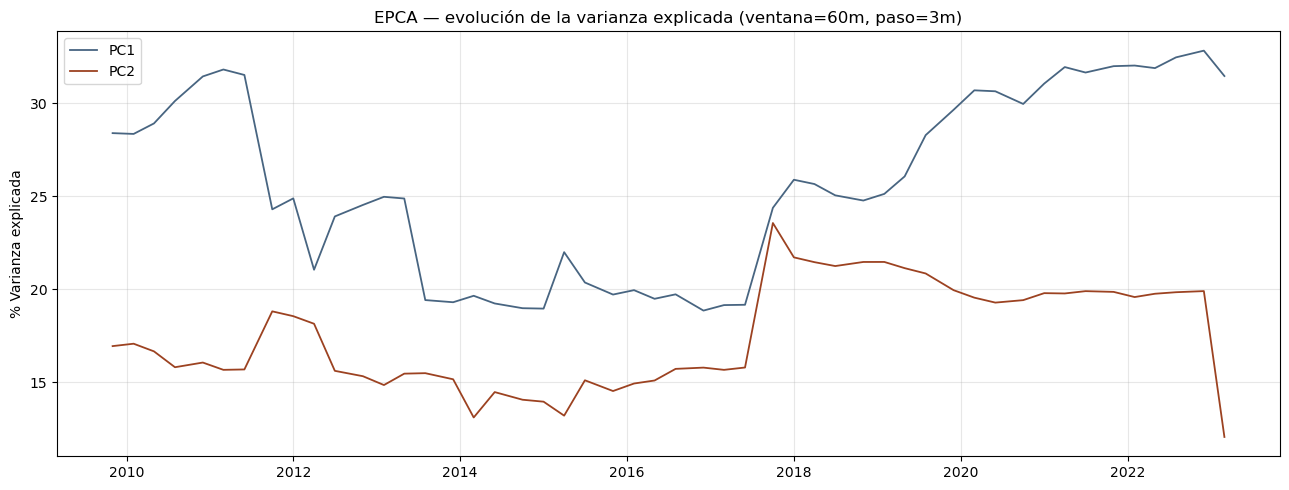

In [4]:
var_pc1 = [v[0] * 100 for v in varianzas_t]
var_pc2 = [v[1] * 100 for v in varianzas_t]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fechas_t, var_pc1, label='PC1', color='#486581', linewidth=1.3)
ax.plot(fechas_t, var_pc2, label='PC2', color='#9c4221', linewidth=1.3)
ax.set_ylabel('% Varianza explicada')
ax.set_title('EPCA — evolución de la varianza explicada (ventana=60m, paso=3m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/06_epca_varianza_evolutiva.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Evolución de las cargas factoriales de PC1

Para las variables con mayor carga promedio en PC1, se grafica cómo
cambia su carga a lo largo de las ventanas -- esto es lo que Camiz,
Maulucci & Roig (2010) llaman "rotación" del componente: si una variable
que dominaba PC1 pierde peso mientras otra lo gana, es evidencia directa
de reconfiguración estructural (posible transición de régimen).

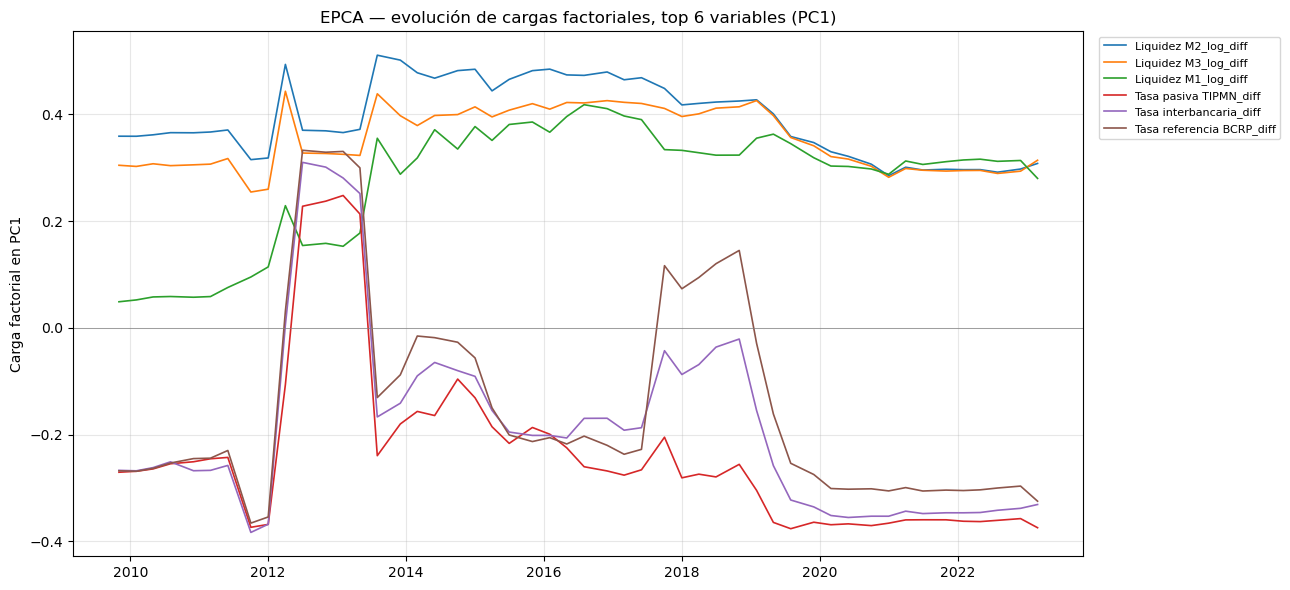

In [5]:
cargas_pc1 = np.array([c[0] for c in cargas_t])  # (n_ventanas, n_variables)
df_cargas_pc1 = pd.DataFrame(cargas_pc1, index=fechas_t, columns=df_transf.columns)

# Alinear signo respecto a la ventana anterior (signo de PCA es arbitrario)
for i in range(1, len(df_cargas_pc1)):
    corr = np.corrcoef(df_cargas_pc1.iloc[i], df_cargas_pc1.iloc[i-1])[0, 1]
    if corr < 0:
        df_cargas_pc1.iloc[i] = -df_cargas_pc1.iloc[i]

top_variables = df_cargas_pc1.abs().mean().sort_values(ascending=False).head(6).index

fig, ax = plt.subplots(figsize=(13, 6))
for var in top_variables:
    ax.plot(df_cargas_pc1.index, df_cargas_pc1[var], label=var, linewidth=1.2)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Carga factorial en PC1')
ax.set_title('EPCA — evolución de cargas factoriales, top 6 variables (PC1)')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/06_epca_cargas_evolutivas.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Estabilidad y detección de transiciones

Mismo criterio ya validado en `06b`: correlación entre cargas de PC1 de
ventanas sucesivas. Se marcan como "transición candidata" los puntos por
debajo de un umbral (media - 1 desviación estándar).

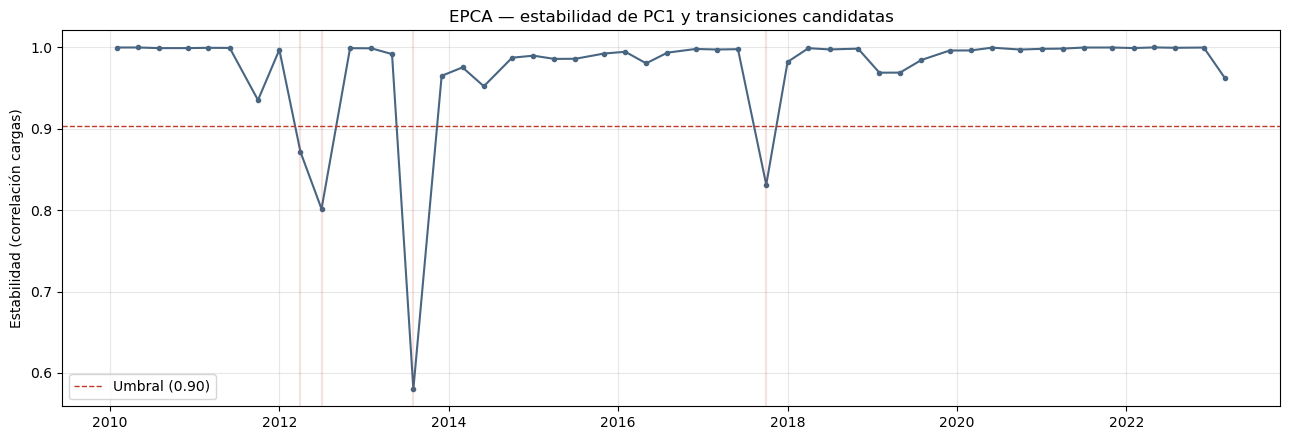

Transiciones candidatas detectadas: 4
  2012-04
  2012-07
  2013-08
  2017-10


In [6]:
estabilidad = [
    np.corrcoef(df_cargas_pc1.iloc[i], df_cargas_pc1.iloc[i-1])[0, 1]
    for i in range(1, len(df_cargas_pc1))
]
fechas_estabilidad = df_cargas_pc1.index[1:]

estab_arr = np.array(estabilidad)
umbral = estab_arr.mean() - estab_arr.std()
transiciones = [fechas_estabilidad[i] for i in range(len(estab_arr)) if estab_arr[i] < umbral]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(fechas_estabilidad, estabilidad, marker='o', markersize=3, color='#486581')
ax.axhline(umbral, color='#c0392b', linestyle='--', linewidth=1, label=f'Umbral ({umbral:.2f})')
for t in transiciones:
    ax.axvline(t, color='#c0392b', alpha=0.15)
ax.set_ylabel('Estabilidad (correlación cargas)')
ax.set_title('EPCA — estabilidad de PC1 y transiciones candidatas')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/06_epca_transiciones.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Transiciones candidatas detectadas: {len(transiciones)}')
for t in transiciones:
    print(f'  {t.strftime("%Y-%m")}')

## 4. EPCA sobre niveles (mensual) — rastreando PC2

Sección abreviada: mismo procedimiento, pero componente_interes=1 (PC2),
por la contaminación de tendencia ya confirmada en PC1.

In [7]:
fechas_n, varianzas_n, cargas_n = epca(df_niveles, VENTANA, PASO, n_componentes=5)
print(f'Ventanas generadas (niveles): {len(fechas_n)}')

Ventanas generadas (niveles): 50


### 4.1 Evolución de la varianza explicada por PC2 y PC3 (niveles)

Se usa PC2 en vez de PC1 como referencia principal (PC1 contaminado por
tendencia), y PC3 como segunda referencia, para mantener el mismo tipo
de gráfico de dos componentes que en la sección 3.1.

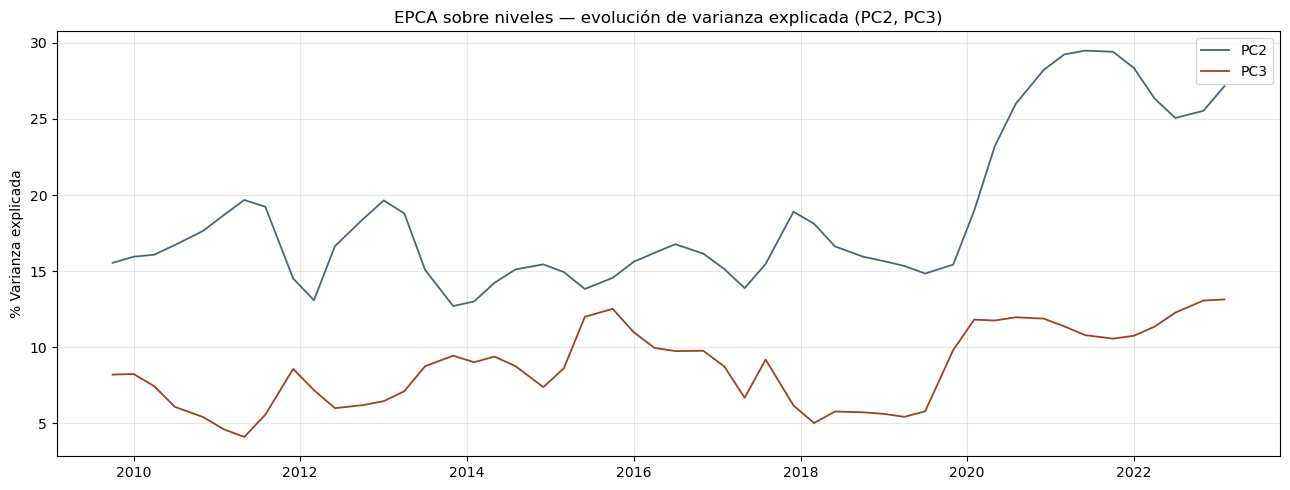

In [8]:
var_pc2_n = [v[1] * 100 for v in varianzas_n]
var_pc3_n = [v[2] * 100 for v in varianzas_n]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fechas_n, var_pc2_n, label='PC2', color='#486581', linewidth=1.3)
ax.plot(fechas_n, var_pc3_n, label='PC3', color='#9c4221', linewidth=1.3)
ax.set_ylabel('% Varianza explicada')
ax.set_title('EPCA sobre niveles — evolución de varianza explicada (PC2, PC3)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/06_epca_varianza_evolutiva_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Evolución de las cargas factoriales de PC2 (niveles)

Mismo procedimiento que la sección 3.2, aplicado a PC2 de niveles.

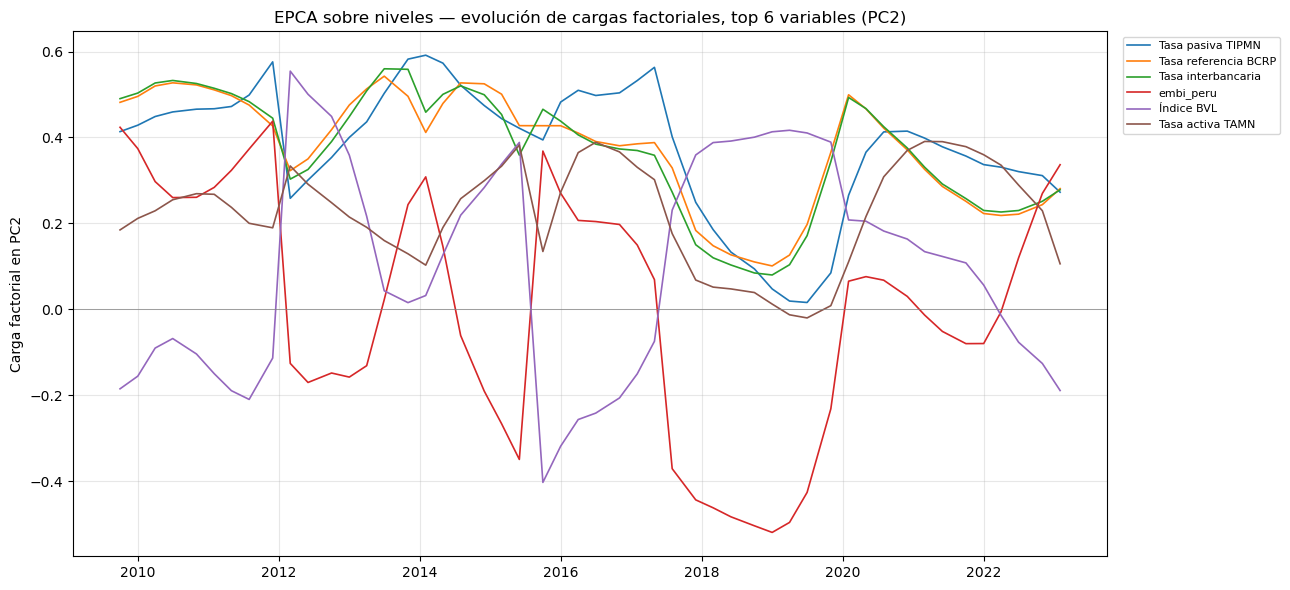

In [9]:
cargas_pc2_niveles = np.array([c[1] for c in cargas_n])
df_cargas_pc2_niveles = pd.DataFrame(cargas_pc2_niveles, index=fechas_n, columns=df_niveles.columns)

for i in range(1, len(df_cargas_pc2_niveles)):
    corr = np.corrcoef(df_cargas_pc2_niveles.iloc[i], df_cargas_pc2_niveles.iloc[i-1])[0, 1]
    if corr < 0:
        df_cargas_pc2_niveles.iloc[i] = -df_cargas_pc2_niveles.iloc[i]

top_variables_niveles = df_cargas_pc2_niveles.abs().mean().sort_values(ascending=False).head(6).index

fig, ax = plt.subplots(figsize=(13, 6))
for var in top_variables_niveles:
    ax.plot(df_cargas_pc2_niveles.index, df_cargas_pc2_niveles[var], label=var, linewidth=1.2)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_ylabel('Carga factorial en PC2')
ax.set_title('EPCA sobre niveles — evolución de cargas factoriales, top 6 variables (PC2)')
ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/06_epca_cargas_evolutivas_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Estabilidad y detección de transiciones (niveles, PC2)

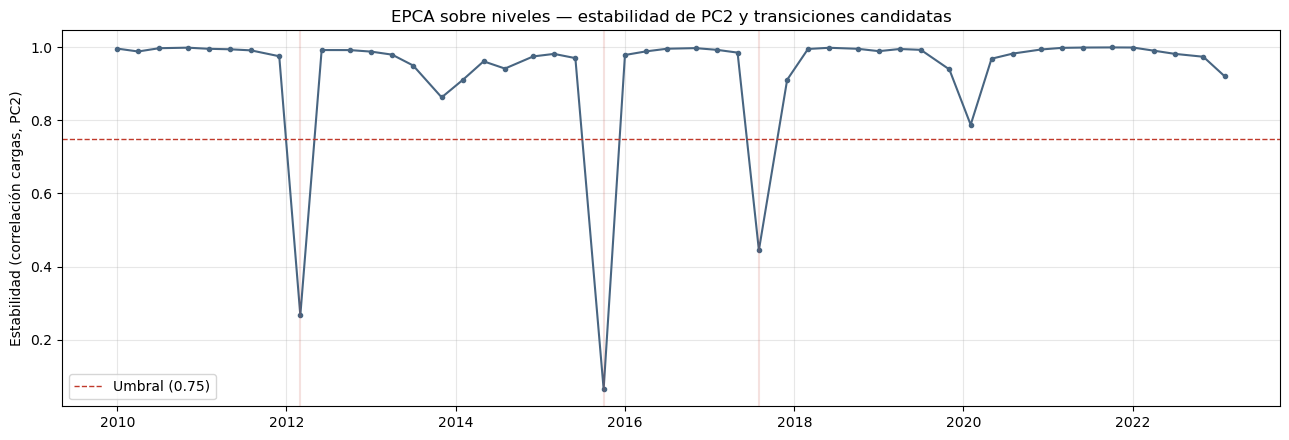

Transiciones candidatas detectadas (niveles, PC2): 3
  2012-03
  2015-10
  2017-08


In [10]:
estabilidad_n = [
    np.corrcoef(df_cargas_pc2_niveles.iloc[i], df_cargas_pc2_niveles.iloc[i-1])[0, 1]
    for i in range(1, len(df_cargas_pc2_niveles))
]
fechas_estabilidad_n = df_cargas_pc2_niveles.index[1:]

estab_arr_n = np.array(estabilidad_n)
umbral_n = estab_arr_n.mean() - estab_arr_n.std()
transiciones_n = [fechas_estabilidad_n[i] for i in range(len(estab_arr_n)) if estab_arr_n[i] < umbral_n]

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(fechas_estabilidad_n, estabilidad_n, marker='o', markersize=3, color='#486581')
ax.axhline(umbral_n, color='#c0392b', linestyle='--', linewidth=1, label=f'Umbral ({umbral_n:.2f})')
for t in transiciones_n:
    ax.axvline(t, color='#c0392b', alpha=0.15)
ax.set_ylabel('Estabilidad (correlación cargas, PC2)')
ax.set_title('EPCA sobre niveles — estabilidad de PC2 y transiciones candidatas')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/06_epca_transiciones_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Transiciones candidatas detectadas (niveles, PC2): {len(transiciones_n)}')
for t in transiciones_n:
    print(f'  {t.strftime("%Y-%m")}')

## 5. Comparación directa: transformado (PC1) vs. niveles (PC2)

¿Ambas variantes detectan transiciones en fechas parecidas, o divergen?
Coincidencias entre ambas son evidencia más fuerte de una transición real
que si solo una variante la detecta.

In [11]:
print('--- Transiciones candidatas: transformado (PC1) ---')
for t in transiciones:
    print(f'  {t.strftime("%Y-%m")}')

print()
print('--- Transiciones candidatas: niveles (PC2) ---')
for t in transiciones_n:
    print(f'  {t.strftime("%Y-%m")}')

# Coincidencias dentro de una ventana de +/- 6 meses
coincidencias = []
for t1 in transiciones:
    for t2 in transiciones_n:
        if abs((t1 - t2).days) <= 180:
            coincidencias.append((t1, t2))

print()
print(f'Coincidencias (dentro de +/- 6 meses): {len(coincidencias)}')
for t1, t2 in coincidencias:
    print(f'  Transformado {t1.strftime("%Y-%m")}  <->  Niveles {t2.strftime("%Y-%m")}')

--- Transiciones candidatas: transformado (PC1) ---
  2012-04
  2012-07
  2013-08
  2017-10

--- Transiciones candidatas: niveles (PC2) ---
  2012-03
  2015-10
  2017-08

Coincidencias (dentro de +/- 6 meses): 3
  Transformado 2012-04  <->  Niveles 2012-03
  Transformado 2012-07  <->  Niveles 2012-03
  Transformado 2017-10  <->  Niveles 2017-08


## 6. Guardar resultados

In [12]:
os.makedirs('data/results', exist_ok=True)

df_varianza = pd.DataFrame({'fecha': fechas_t, 'var_pc1': var_pc1, 'var_pc2': var_pc2})
df_varianza.to_csv('data/results/06_epca_varianza_explicada.csv', index=False)

df_cargas_pc1.to_csv('data/results/06_epca_cargas_evolutivas.csv')
df_cargas_pc2_niveles.to_csv('data/results/06_epca_cargas_evolutivas_niveles.csv')

df_transiciones = pd.DataFrame({'fecha_transicion_candidata': transiciones})
df_transiciones.to_csv('data/results/06_epca_transiciones_detectadas.csv', index=False)

df_transiciones_niveles = pd.DataFrame({'fecha_transicion_candidata': transiciones_n})
df_transiciones_niveles.to_csv('data/results/06_epca_transiciones_detectadas_niveles.csv', index=False)

print('Resultados guardados en data/results/:')
print('  - 06_epca_varianza_explicada.csv')
print('  - 06_epca_cargas_evolutivas.csv / 06_epca_cargas_evolutivas_niveles.csv')
print('  - 06_epca_transiciones_detectadas.csv / 06_epca_transiciones_detectadas_niveles.csv')

Resultados guardados en data/results/:
  - 06_epca_varianza_explicada.csv
  - 06_epca_cargas_evolutivas.csv / 06_epca_cargas_evolutivas_niveles.csv
  - 06_epca_transiciones_detectadas.csv / 06_epca_transiciones_detectadas_niveles.csv


In [13]:
import pandas as pd
for archivo in [
    'data/processed/dataset_estandarizado_trimestral.csv',
    'data/processed/dataset_niveles_estandarizado_trimestral.csv',
    'data/processed/dataset_estandarizado_mensual.csv',
    'data/processed/dataset_niveles_estandarizado_mensual.csv',
]:
    df = pd.read_csv(archivo, index_col=0)
    print(f'{archivo}: {df.shape}')

data/processed/dataset_estandarizado_trimestral.csv: (72, 18)
data/processed/dataset_niveles_estandarizado_trimestral.csv: (73, 20)
data/processed/dataset_estandarizado_mensual.csv: (208, 17)
data/processed/dataset_niveles_estandarizado_mensual.csv: (209, 19)
